In [ ]:
#Project: No-Show Appointment Analysis & Prediction Project
#Team: Aaliya Shaikh & Pranay Karande
#Date: 04/07/2025

In [ ]:
# Install if necessary
# !pip install seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# Load dataset
df = pd.read_csv("KaggleV2-May-2016.csv")  # use actual path if needed

# Clean column names
df.columns = [col.strip().replace('-', '_') for col in df.columns]

# Convert date columns
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create new features
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days
df['AppointmentWeekDay'] = df['AppointmentDay'].dt.day_name()
df['No_show'] = df['No_show'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'F': 'Female', 'M': 'Male'})

# Drop unnecessary columns
df.drop(['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay'], axis=1, inplace=True)


<ipython-input-18-d6d28e9b416b>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Gender', y='No_show', palette='coolwarm')


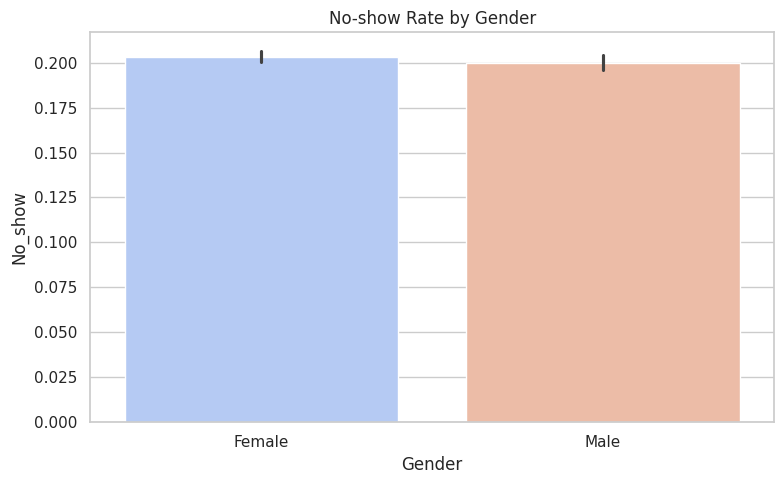

<ipython-input-18-d6d28e9b416b>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='AgeGroup', y='No_show', palette='viridis')


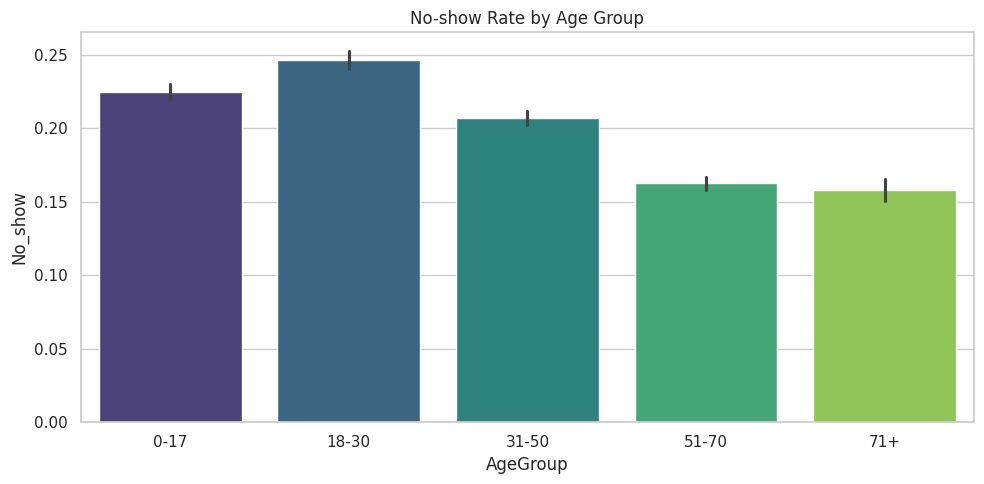

<ipython-input-18-d6d28e9b416b>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='AppointmentWeekDay', y='No_show', palette='magma', order=[


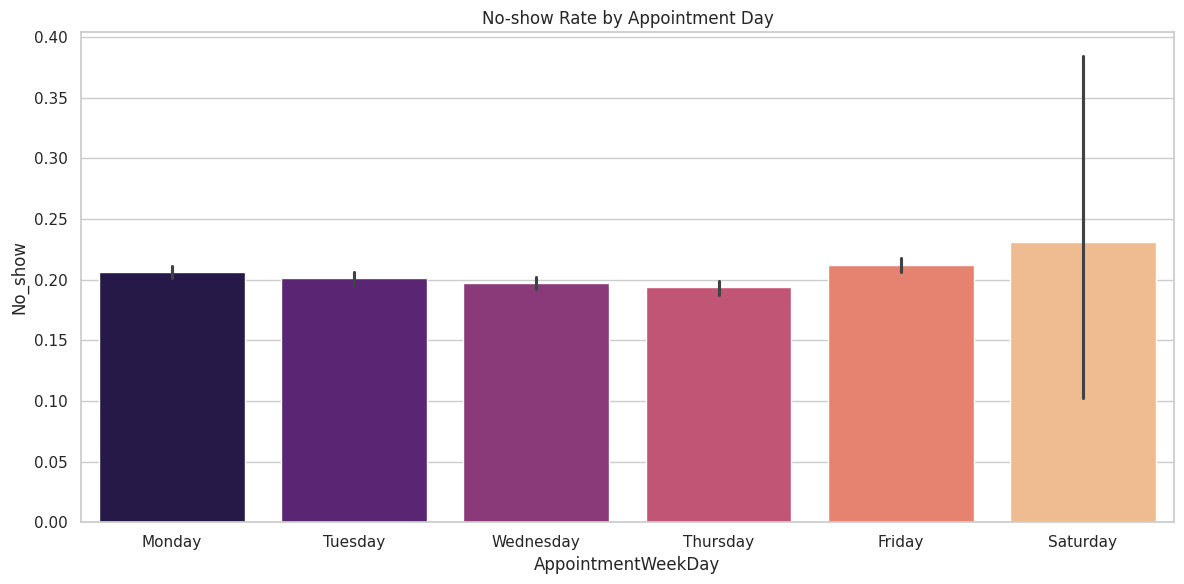

<ipython-input-18-d6d28e9b416b>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['WaitingDays'] <= 50], x='No_show', y='WaitingDays', palette='Set2')


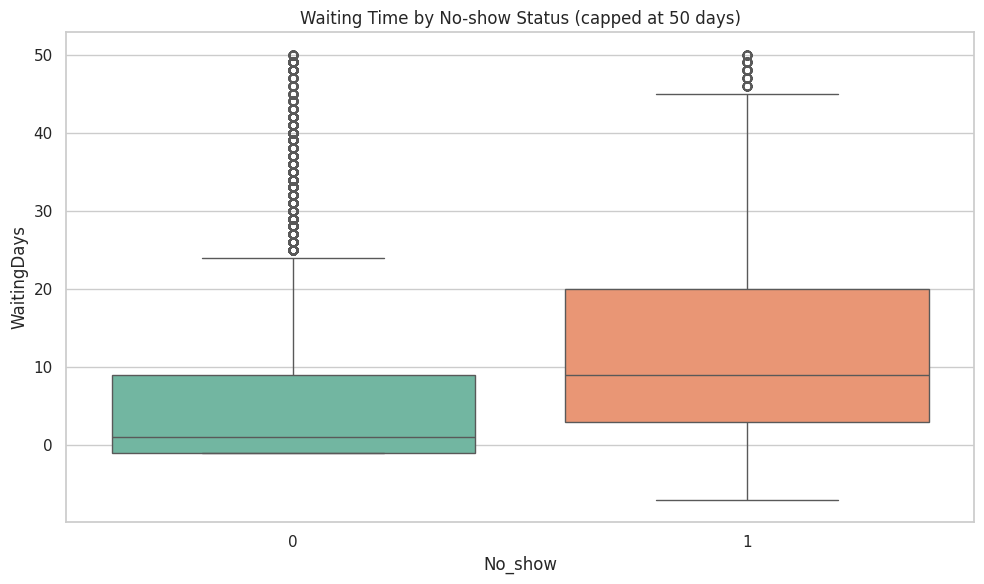

In [ ]:
sns.set(style="whitegrid")

# Create AgeGroup for visualization
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 17, 30, 50, 70, 100],
                        labels=['0-17', '18-30', '31-50', '51-70', '71+'])

# 1. No-show Rate by Gender
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Gender', y='No_show', palette='coolwarm')
plt.title('No-show Rate by Gender')
plt.tight_layout()
plt.show()

# 2. No-show Rate by Age Group
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='AgeGroup', y='No_show', palette='viridis')
plt.title('No-show Rate by Age Group')
plt.tight_layout()
plt.show()

# 3. No-show Rate by Day of the Week
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='AppointmentWeekDay', y='No_show', palette='magma', order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
plt.title('No-show Rate by Appointment Day')
plt.tight_layout()
plt.show()

# 4. Waiting Days vs No-show
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['WaitingDays'] <= 50], x='No_show', y='WaitingDays', palette='Set2')
plt.title('Waiting Time by No-show Status (capped at 50 days)')
plt.tight_layout()
plt.show()


In [ ]:
# Encode Neighbourhood, Gender, AppointmentWeekDay
label_encoders = {}
for col in ['Gender', 'AppointmentWeekDay', 'Neighbourhood']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [ ]:
# Drop AgeGroup (used only for EDA)
X = df.drop(['No_show', 'AgeGroup'], axis=1)
y = df['No_show']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


Accuracy: 0.7815977562652674

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87     17669
           1       0.42      0.22      0.28      4437

    accuracy                           0.78     22106
   macro avg       0.62      0.57      0.58     22106
weighted avg       0.74      0.78      0.75     22106



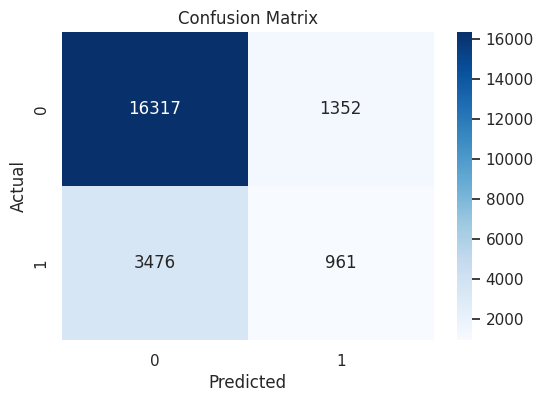

In [ ]:
# Accuracy & report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


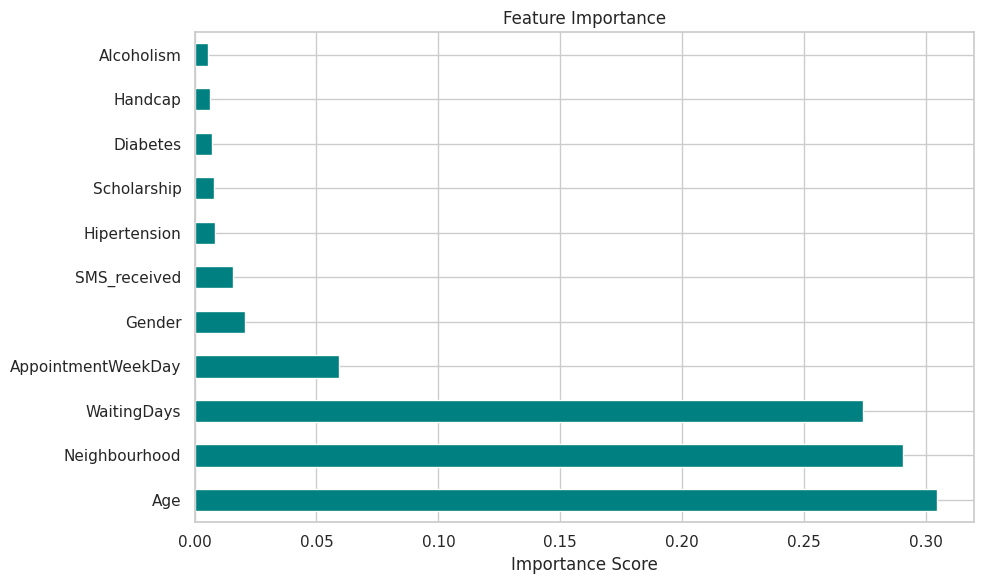

In [ ]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


In [23]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.7815977562652674


SQL SKillset

In [25]:
import sqlite3
import pandas as pd

# Load the CSV
df = pd.read_csv("KaggleV2-May-2016.csv")

# Connect to an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Save DataFrame as SQL table
df.to_sql('appointments', conn, index=False, if_exists='replace')


110527

In [26]:
# Query 1: Count total appointments
query1 = pd.read_sql("SELECT COUNT(*) AS total_appointments FROM appointments", conn)
print(query1)

# Query 2: Find top 5 neighborhoods by no-show rate
query2 = pd.read_sql("""
SELECT Neighbourhood,
       SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS no_show_rate
FROM appointments
GROUP BY Neighbourhood
ORDER BY no_show_rate DESC
LIMIT 5
""", conn)
print(query2)

# Query 3: Get no-show stats by day of the week
query3 = pd.read_sql("""
SELECT strftime('%w', AppointmentDay) AS weekday,
       COUNT(*) AS total,
       SUM(CASE WHEN "No-show" = 'Yes' THEN 1 ELSE 0 END) AS no_shows
FROM appointments
GROUP BY weekday
ORDER BY weekday
""", conn)
print(query3)


   total_appointments
0              110527
                 Neighbourhood  no_show_rate
0  ILHAS OCEÂNICAS DE TRINDADE      1.000000
1                SANTOS DUMONT      0.289185
2                SANTA CECÍLIA      0.274554
3                  SANTA CLARA      0.264822
4                      ITARARÉ      0.262664
  weekday  total  no_shows
0       1  22715      4690
1       2  25640      5152
2       3  25867      5093
3       4  17247      3338
4       5  19019      4037
5       6     39         9


### 🛡️ Data Privacy & Ethics (HIPAA)

Although this dataset is publicly available and de-identified, real-world patient data must be handled with strict compliance to HIPAA guidelines, including:

- **De-identification**: Removing or encrypting any personally identifiable information (PII).
- **Data Access Control**: Ensuring only authorized personnel can view sensitive data.
- **Data Security**: Implementing encryption, secure storage, and audit trails.
- **Ethical Use**: Analyzing data only for approved and beneficial purposes.

If working with real clinical data, I would follow HIPAA best practices and institutional review board (IRB) protocols.
